In [1]:
import tensorflow as tf
import numpy as np
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import matplotlib.pyplot as plt
from keras.models import load_model
plt.rcParams.update({'font.size': 16})
import time
import numpy as np
from hilbert import decode, encode
import keras
from tf_fourier_features import FourierFeatureProjection

from numpy import loadtxt
import tensorflow as tf
import numpy as np
from scipy.stats.qmc import Sobol
plt.rcParams.update({'font.size': 18})
import matplotlib as mpl
import matplotlib.ticker as ticker
import os
from PIL import Image
from distutils.version import LooseVersion
import skopt


In [2]:
dtype = 'float32'
rs = lambda x:tf.reshape(tf.convert_to_tensor(x,dtype=dtype),(-1,1))
rs2 = lambda x:tf.reshape(tf.convert_to_tensor(x,dtype=dtype),(-1,2))
sin = lambda x:tf.math.sin(x)
cos = lambda x:tf.math.cos(x)
abs = lambda x:tf.math.abs(x)
mse = lambda x:tf.reduce_mean(tf.square(x))


In [3]:
class SimulationConfig:
    def __init__(self):
        # -------------------------------------------------------
        # Base constants and ranges
        # -------------------------------------------------------
        self.dtype = 'float32'
        self.xmin, self.ymin = 0.0, 0.0
        self.xmax, self.ymax = 1.0, 1.0
        self.tmin, self.tmax = 0.0, 1.0

        # Geometry
        self.X = 0.1
        self.Y = 0.1
        self.T_ = 1800.0

        # Model parameters
        self.kappa = 1.0
        self.kappas = 0.9
        self.kappaa = self.kappa - self.kappas
        self.A = 0.3






        # Radiation constants
        self.sigma = 5.67036713e-8
        self.thetas = 1200.
        self.n = 1.5

        # Two-material case parameters
        self.k = 1.65
        self.rho = 2600
        self.cv = 838

        # Additional parameters
        self.gmin = 0.0001
        self.gmax = 0.5
        self.theta0 = 0.9
        self.thetabc = 0.3#+0.7*t
        self.thetad = 0.5

        self.Bi = lambda h, k: h * self.X / k

        self.alpha = self.X * self.kappaa
        self.nn = 4 * self.n**2

        self.d = self.X / self.Y
        self.S = self.X**(-1) / (3 * self.kappa - self.A * self.kappas)

        # Material 1 and 2
        self.chi = self.k / (self.rho * self.cv)
        self.Fo = self.T_ * self.chi / self.X**2
        self.Bir = self.sigma * self.thetas**3 * self.X# / self.k1


        self.N_0 = 8000
        self.N_b = 10000
        self.N_r = 60000#40000    
        self.N_tmp = 4
        self.ex = 0.01


    # -----------------------------------------------------------
    def summary(self):
        """Print important values."""
        print("chi:", self.chi)
        print("Fo:", self.Fo)
        print("Bir:", self.Bir)
        print("alpha:", self.alpha)
        print("nn:", self.nn)
        print("d:", self.d)
        print("S:", self.S)

In [4]:

class PDEFunctions:
    def __init__(self, config):
        # store config locally
        self.cfg = config

    # -----------------------------------------------------------
    # Boundary/initial condition functions
    # -----------------------------------------------------------
    def fun_theta_0(self, X):
        t = X[:, 2:3]
        n = t.shape[0]
        return tf.ones((n, 1), dtype=cfg.dtype) * 0.9

    def fun_theta_b(self, X):
        t = X[:, 2:3]
        n = t.shape[0]
        return tf.ones((n, 1), dtype=cfg.dtype) * 0.3

    def fun_theta_tmp(self, X):
        t = X[:, 2:3]
        n = t.shape[0]
        return tf.ones((n, 1), dtype=cfg.dtype) * 0.9-0.4*t

    # -----------------------------------------------------------
    # PDE residuals
    # -----------------------------------------------------------
    def r_1(self, x, y, t, theta, thetax, thetay, thetat,
             thetaxx, thetayy, phi):
        return (
            thetat
            - self.cfg.Fo * (thetaxx + self.cfg.d**2 * thetayy)
            + self.cfg.Fo * self.cfg.Bir/self.cfg.k * self.cfg.alpha * self.cfg.nn * (theta**4 - phi)
        ) 



    def r_2(self, x, y, t, phi, phixx, phiyy, theta):
        return (-self.cfg.S * (phixx + self.cfg.d**2 * phiyy) + self.cfg.alpha * (phi - theta**4)) / self.cfg.S

    # -----------------------------------------------------------
    # Boundary flux functions
    # -----------------------------------------------------------
    def fun_beta(self, theta, thetax, thetay, nx, ny, h):
        return (thetax * nx + self.cfg.d * thetay * ny) + h * (theta - self.cfg.thetabc)

    def fun_gamma(self, phi, phix, phiy, nx, ny, gamma_val):

        return (self.cfg.S * (phix * nx + self.cfg.d * phiy * ny) + gamma_val * (phi - self.cfg.thetabc**4)) 

In [5]:

class DataGenerator:
    def __init__(self, config, pde_funcs):
        self.cfg = config
        self.pde = pde_funcs
        self.X_data = []
        self.u_data = []
        self.w_data = []
        self.n_data = []
        self.x_b2 = rs(np.linspace(2.789,3.037,200))        
        self.y_b2 = (-tf.math.sqrt(1/4-(self.x_b2*2.5+2.5-3.25)**2)+1.3)/1.8
        self.xp = None

        self.generate()
    # -----------------------------------------------------------
    # Sobol generator
    # -----------------------------------------------------------
    def quasirandom(self,n_samples, sampler,ex,d):
        space = [(0.0+ex, 1.0-ex)]*d
        if sampler == "LHS":
            sampler = skopt.sampler.Lhs(
                lhs_type="centered", criterion="maximin", iterations=1000
            )
        elif sampler == "Halton":
            sampler = skopt.sampler.Halton(min_skip=-1, max_skip=-1)
        elif sampler == "Hammersley":
            sampler = skopt.sampler.Hammersly(min_skip=-1, max_skip=-1)
        elif sampler == "Sobol":
            # Remove the first point [0, 0, ...] and the second point [0.5, 0.5, ...], which
            # are too special and may cause some error.
            if LooseVersion(skopt.__version__) < LooseVersion("0.9"):
                sampler = skopt.sampler.Sobol(min_skip=2, max_skip=2, randomize=False)
            else:
                sampler = skopt.sampler.Sobol(skip=0, randomize=False)
                return np.array(
                    sampler.generate(space, n_samples + 2)[2:]
                )
        return np.array(sampler.generate(space, n_samples))

    def make_x(self,i,xp,Ns):
        return rs(np.linspace(xp[2*i], xp[2*i+1], Ns[i]))
    
    def rnd_t(self,N,ex): 
        return tf.random.uniform((N,1), ex, 1)
    
    def cat(self,x, y, t): 
        return tf.concat([x, y, t], axis=1)
        # ----- normals helpers -----
    def norm2(self,a, b):
            d = tf.sqrt(a*a + b*b)
            return [a/d, b/d]        
    # -----------------------------------------------------------
    # Main dataset generation function
    # -----------------------------------------------------------
    def gen_X_b(self):
        cc = 4
        ex = 0.01
        
        self.xp = np.array([2.756,3.75,2.789,3.037,3.703,3.75,3.,5.,4.783,5.,
                       3.0,3.037,3.703,4.783,2.5,2.756,2.5,2.789])/2.5 - 1
        
        Ns = cc * np.array([2000,200,200,4000,500,300,1000,100,100])
        # ----- x values -----
        xs = [self.make_x(i,self.xp,Ns) for i in range(9)]
        
        # ----- y functions -----
        y_funcs = [
            lambda x: ( tf.sqrt(.25 - (2.5*x+2.5-3.25)**2) + 1.3)/1.8,
            lambda x: (-tf.sqrt(.25 - (2.5*x+2.5-3.25)**2) + 1.3)/1.8,
            lambda x: (-tf.sqrt(.25 - (2.5*x+2.5-3.25)**2) + 1.3)/1.8,
            lambda x: (-tf.sqrt(1 - (2.5*x+2.5-4)**2) + 1)/1.5/1.8,
            lambda x: ( tf.sqrt(1 - (2.5*x+2.5-4)**2) + 1)/1.5/1.8,
            lambda x: ( tf.sqrt(1 - (2.5*x+2.5-4)**2) + 1)/1.5/1.8,
            lambda x: ((2.5*x+2.5-4.25)**4 + 1)/1.8,
            lambda x: (0.5*(2.5*x+2.5))/1.8,
            lambda x: (-0.5*(2.5*x+2.5)+2.5)/1.8
        ]
        
        ys = [f(xs[i]) for i, f in enumerate(y_funcs)]
        ts = [self.rnd_t(Ns[i],0.) for i in range(9)]
        
        # ----- stack boundary points -----
        X_b = [self.cat(xs[i], ys[i], ts[i]) for i in range(9)]
        

        
        N = [
            self.norm2(5*xs[0]-1.5, 3.6*ys[0]-2.6),
            self.norm2(5*xs[1]-1.5, 3.6*ys[1]-2.6),
            self.norm2(5*xs[2]-1.5, 3.6*ys[2]-2.6),
            self.norm2(5*xs[3]-3.0, 5.4*ys[3]-2.0),
            self.norm2(5*xs[4]-3.0, 5.4*ys[4]-2.0),
            self.norm2(5*xs[5]-3.0, 5.4*ys[5]-2.0),
            self.norm2(-10*(2.5*xs[6]-1.75)**3, 1.8),
            self.norm2(-1.25 + xs[7]*0.0,  1.8 + xs[7]*0.0),
            self.norm2(-1.25 + xs[8]*0.0, -1.8 + xs[8]*0.0),
        ]
        
        # ----- merge everything -----
        fun_thetab = self.pde.fun_theta_b(X_b[0])
        
        X_bb = tf.concat(X_b, axis=0)
        n_bb = tf.concat([tf.concat(n, axis=1) for n in N], axis=0)

        return X_bb,n_bb

    def gen_X_0(self):
        ex = 0.001
        xp = self.xp
        X_0 = tf.convert_to_tensor(self.quasirandom(self.cfg.N_0,'Sobol',0.0,2),dtype=dtype)
        X_0 = tf.boolean_mask(X_0, tf.where((X_0[:,1] <((1*tf.math.sqrt(1-(X_0[:,0]*2.5+2.5-4)**2)+1)/1.5)/1.8)|(((X_0[:,0])<xp[8])), True, False))
        
        X_0 = tf.boolean_mask(X_0, tf.where((X_0[:,1] <(1/2*(X_0[:,0]*2.5+2.5))/1.8)|(X_0[:,0]>xp[15]), True, False))
        X_0 = tf.boolean_mask(X_0, tf.where((X_0[:,1] >(-1/2*(X_0[:,0]*2.5+2.5)+2.5)/1.8)|(X_0[:,0]>xp[17]), True, False))
        X_0 = tf.boolean_mask(X_0, tf.where((X_0[:,1] <(tf.math.sqrt(1/4 - (2.5*X_0[:,0]+2.5-3.25)**2)+1.3)/1.8)|((X_0[:,0]<xp[0]))|((X_0[:,0]>xp[1])), True, False))
        
        X_0 = tf.boolean_mask(X_0, tf.where((X_0[:,1] <((X_0[:,0]*2.5+2.5-4.25)**4+1)/1.8)|(X_0[:,1] <(tf.math.sqrt(1/4 - (2.5*X_0[:,0]+2.5-3.25)**2)+1.3)/1.8)&(X_0[:,1] >(-tf.math.sqrt(1/4-(X_0[:,0]*2.5+2.5-3.25)**2)+1.3)/1.8)     , True, False))
        X_0 = tf.boolean_mask(X_0, tf.where((X_0[:,1] >((-1*tf.math.sqrt(1-(X_0[:,0]*2.5+2.5-4)**2)+1)/1.5)/1.8)&(X_0[:,1] <((1*tf.math.sqrt(1-(X_0[:,0]*2.5+2.5-4)**2)+1)/1.5)/1.8)|(X_0[:,1]>0.47018567), True, False))
        X_0 = tf.boolean_mask(X_0, tf.where((X_0[:,1] >(-tf.math.sqrt(1/4-(X_0[:,0]*2.5+2.5-3.25)**2)+1.3)/1.8)|(X_0[:,1] <=(tf.reduce_min(self.y_b2))-0.001)|(X_0[:,1] >=(tf.reduce_max(self.y_b2)))|(X_0[:,0] >=0.3), True, False))
        
        t_0 = tf.random.uniform((len(X_0),1),0,0,dtype=dtype)    
        X_0 = tf.concat([X_0,t_0],axis=1)
        return X_0  

    def gen_X_tmp(self):
        ex = self.cfg.ex
        xp = self.xp
        # (N, left_idx, right_idx, y_function, extra_ex_left)
        cfg = [
            (5,  0,  1, lambda x: ( tf.sqrt(0.25 - (2.5*x+2.5-3.25)**2)+1.3)/1.8, 1),
            (3,  2,  3, lambda x: (-tf.sqrt(0.25 - (2.5*x+2.5-3.25)**2)+1.3)/1.8, 1),
            (10, 6,  7, lambda x: (-tf.sqrt(1 - (2.5*x+2.5-4)**2)+1)/1.5/1.8,      1),
            (3,  8,  9, lambda x: ( tf.sqrt(1 - (2.5*x+2.5-4)**2)+1)/1.5/1.8,      1),
            (5, 12, 13, lambda x: ((2.5*x+2.5-4.25)**4+1)/1.8,                       1),
            (1, 14, 15, lambda x: (0.5*(2.5*x+2.5))/1.8,                             5),
            (1, 16, 17, lambda x: (-0.5*(2.5*x+2.5)+2.5)/1.8,                        5),
        ]
        
        # build x/y blocks
        xs, ys = [], []
        for N, l, r, f, k in cfg:
            x = rs(np.linspace(xp[l] + k*ex, xp[r] - ex, N))
            xs.append(x)
            ys.append(f(x))
        
        # concat x and y
        x_tmp = tf.concat(xs, axis=0)
        y_tmp = tf.concat(ys, axis=0)
        XY = tf.concat([x_tmp, y_tmp], axis=1)
        
        # time expansion
        t_vals = tf.range(0, 11, dtype=XY.dtype) / 10 * self.cfg.tmax               # shape (11,)
        t_vals = tf.reshape(t_vals, (-1, 1, 1))                            # (11,1,1)
        XY_rep  = tf.expand_dims(XY, 0)                                     # (1,N,2)
        
        T = tf.ones_like(XY_rep[:, :, :1]) * t_vals                         # (11,N,1)
        X_tmp = tf.concat([tf.tile(XY_rep, [11,1,1]), T], axis=2)            # (11,N,3)
        X_tmp = tf.reshape(X_tmp, (-1, 3))                                   # (11*N,3)
        return X_tmp
    def gen_X_r(self):
        ex = self.cfg.ex*2
        xp = self.xp       
        X_r = tf.convert_to_tensor(self.quasirandom(self.cfg.N_r,'Sobol',0.0,3),dtype=dtype)
        X_r = tf.boolean_mask(X_r, tf.where((X_r[:,1] >((-1*tf.math.sqrt(1+-(X_r[:,0]*2.5+2.5-4)**2)+1)/1.5)/1.8)|((X_r[:,0])<xp[6]), True, False))
        X_r = tf.boolean_mask(X_r, tf.where((X_r[:,1] <((1*tf.math.sqrt(1-ex-(X_r[:,0]*2.5+2.5-4)**2)+1)/1.5)/1.8)|(((X_r[:,0])<xp[8]-ex)), True, False))
        
        X_r = tf.boolean_mask(X_r, tf.where((X_r[:,1] <(-ex/2 + 1/2*(X_r[:,0]*2.5+2.5))/1.8)|(X_r[:,0]>xp[15]), True, False))
        X_r = tf.boolean_mask(X_r, tf.where((X_r[:,1] >(ex/2-1/2*(X_r[:,0]*2.5+2.5)+2.5)/1.8)|(X_r[:,0]>xp[17]), True, False))
        
        X_r = tf.boolean_mask(X_r, tf.where((X_r[:,1] <(tf.math.sqrt(1/4-ex - (2.5*X_r[:,0]+2.5-3.25)**2)+1.3)/1.8)|((X_r[:,0]<xp[0]))|(((X_r[:,0]>xp[1]-0.1))&(X_r[:,1]<0.6)), True, False))
        #X_r = tf.boolean_mask(X_r, tf.where((X_r[:,1] <((1*tf.math.sqrt(1-(X_r[:,0]*2.5+2.5-4)**2)+1)/1.5)/1.8)|((X_r[:,0]>xp[10]))|((X_r[:,0]<xp[11])), True, False))
        
        X_r = tf.boolean_mask(X_r, tf.where( (X_r[:,0]>0.205)|(X_r[:,1]>0.48), True, False))
        X_r = tf.boolean_mask(X_r, tf.where( (X_r[:,0]>0.125)|(X_r[:,1]>0.605), True, False))
        
        X_r = tf.boolean_mask(X_r, tf.where((X_r[:,1] <((X_r[:,0]*2.5+2.5-4.25)**4+1-ex)/1.8)|(X_r[:,1] <(tf.math.sqrt(1/4 - (2.5*X_r[:,0]+2.5-3.25-ex)**2)+1.3)/1.8)&(X_r[:,1] >(-tf.math.sqrt(1/4-(X_r[:,0]*2.5+2.5-3.25)**2)+1.3+ex)/1.8)     , True, False))
        X_r = tf.boolean_mask(X_r, tf.where((X_r[:,1] >((-1*tf.math.sqrt(1-ex-(X_r[:,0]*2.5+2.5-4)**2)+1)/1.5)/1.8)&(X_r[:,1] <((1*tf.math.sqrt(1-(X_r[:,0]*2.5+2.5-4)**2)+1)/1.5)/1.8)|(X_r[:,1]>0.47018567), True, False))
        X_r = tf.boolean_mask(X_r, tf.where((X_r[:,1] >(-tf.math.sqrt(1/4-ex-(X_r[:,0]*2.5+2.5-3.25)**2)+1.3)/1.8)|(X_r[:,1] <=(tf.reduce_min(self.y_b2))-0.001)|(X_r[:,1] >=(tf.reduce_max(self.y_b2)))|(X_r[:,0] >=0.3), True, False))
        
        X_r = tf.boolean_mask(X_r, tf.where(X_r[:,2] >ex, True, False))

        return X_r
    def generate(self, ex=0.01):
        cfg = self.cfg

        # ------------------------------------------------------------------
        # Residual / interior points
        # ------------------------------------------------------------------

        X_b,n_b = self.gen_X_b()
        X_0 = self.gen_X_0()
        X_tmp = self.gen_X_tmp()
        X_r = self.gen_X_r()
      
        # Target values
        fun_theta0 = self.pde.fun_theta_0(X_0)
        fun_thetatmp = self.pde.fun_theta_tmp(X_tmp)

        # ------------------------------------------------------------------
        # Weights
        # ------------------------------------------------------------------
        w_r = tf.Variable(tf.ones([len(X_r), 1], dtype=cfg.dtype))
        w_b = tf.Variable(tf.ones([len(X_b), 1], dtype=cfg.dtype))
        w_0 = tf.Variable(tf.ones([len(X_0), 1], dtype=cfg.dtype))
        w_tmp = tf.Variable(tf.ones([len(X_tmp), 1], dtype=cfg.dtype))

        X_data = [X_r, X_b, X_0, X_tmp]
        u_data = [fun_theta0, fun_thetatmp]
        w_data = [w_r, w_b, w_0, w_tmp]
        n_data = n_b#[n_b1, n_b2]

        self.X_data = X_data
        self.u_data = u_data
        self.w_data = w_data
        self.n_data = n_data
#        return X_data, u_data, w_data, n_data

In [34]:
class Visualization:
    def __init__(self,config,gen, PINN):
        self.cfg = config
        self.gen = gen
        self.PINN = PINN

    
    @tf.function
    def build_mask(self, X_r, ex):
        # Force consistent dtype
        X_r = tf.cast(X_r, tf.float32)
    
        x = X_r[:, 0]
        y = X_r[:, 1]
    
        # ---- Masks ----
    
        m1 = (y >= ((-tf.math.sqrt(1 - (x*2.5 + 2.5 - 4)**2) + 1)/1.5)/1.8) | (x < self.gen.xp[6])
    
        m2 = (y <= (( tf.math.sqrt(1 - ex - (x*2.5 + 2.5 - 4)**2) + 1)/1.5)/1.8) | (x < self.gen.xp[8] - ex)
    
        m3 = (y <= (-ex/2 + 0.5*(x*2.5 + 2.5))/1.8) | (x > self.gen.xp[15])
    
        m4 = (y >= (ex/2 - 0.5*(x*2.5 + 2.5) + 2.5)/1.8) | (x > self.gen.xp[17])
    
        m5 = (
            (y <= (tf.math.sqrt(1/4 - ex - (2.5*x + 2.5 - 3.25)**2) + 1.3)/1.8) |
            (x < self.gen.xp[0]) |
            ((x > self.gen.xp[1] - 0.1) & (y < 0.6))
        )
    
        m6 = (x > 0.205) | (y >= 0.48)
        m7 = (x > 0.125) | (y >= 0.605)
    
        m8 = (
            (y <= ((x*2.5 + 2.5 - 4.25)**4 + 1 - ex)/1.8) |
            (
                (y <= (tf.math.sqrt(1/4 - (2.5*x + 2.5 - 3.25 - ex)**2) + 1.3)/1.8) &
                (y >= (-tf.math.sqrt(1/4 - (x*2.5 + 2.5 - 3.25)**2) + 1.3 + ex)/1.8)
            )
        )
    
        m9 = (
            (
                (y >= ((-tf.math.sqrt(1 - ex - (x*2.5 + 2.5 - 4)**2) + 1)/1.5)/1.8) &
                (y <= (( tf.math.sqrt(1 - (x*2.5 + 2.5 - 4)**2) + 1)/1.5)/1.8)
            ) | (y >= 0.47018567)
        )
    
        # dtype-safe bounds
        y_b2 = tf.cast(self.gen.y_b2, tf.float32)
        min_b2 = tf.reduce_min(y_b2)
        max_b2 = tf.reduce_max(y_b2)
    
        m10 = (
            (y >= (-tf.math.sqrt(1/4 - ex - (x*2.5 + 2.5 - 3.25)**2) + 1.3)/1.8)|#/1.8) 
            
            (y <= 0.48) |
            (y >= 0.6) |
            (x >= 0.3)
        )
#        X_r = tf.boolean_mask(X_r, tf.where((X_r[:,1] >(-tf.math.sqrt(1/4-ex-(X_r[:,0]*2.5+2.5-3.25)**2)+1.3)/1.8)|(X_r[:,1] <=(tf.reduce_min(self.y_b2))-0.001)|(X_r[:,1] >=(tf.reduce_max(self.y_b2)))|(X_r[:,0] >=0.3), True, False))
            
        # ---- Final boolean mask ----
        mask = m1 & m2 & m3 & m4 & m5 & m6 & m7 & m8 & m9 & m10
    
        return mask

        
    def plotu(self, i=0., N=1., save=False, path=None, show=True):
        scale1 = 1.0
        scale2 = 0.0
        NN = 100
        size = 30
        BS = 4096  # batch size for safe GPU inference
    

    # ---- Grid ----
        xspace = np.linspace(0, self.cfg.xmax, NN + 1)
        yspace = np.linspace(0, self.cfg.ymax, NN + 1)
        xx, yy = np.meshgrid(xspace, yspace)
    
        Xgrid = np.column_stack([xx.ravel(), yy.ravel()])
        tcol = np.full((Xgrid.shape[0], 1), i / N)
        XTgrid = np.hstack([Xgrid, tcol]).astype(np.float32)
    
        # ---- Model predictions ----
        tmp1 = self.PINN.models[0](XTgrid)
        tmp2 = self.PINN.models[1](XTgrid)
    
        U1 = tmp1.numpy().reshape(NN+1, NN+1)
        U2 = tmp2.numpy().reshape(NN+1, NN+1)
    
        # ---- Build mask correctly ----
        mask = self.build_mask(XTgrid, 0.0)
    
        # Tensor -> NumPy
        mask = mask.numpy().reshape(NN + 1, NN + 1)
    
        # ---- Apply mask ----
        U1m = np.where(mask, U1, np.nan)
        U2m = np.where(mask, U2, np.nan)
        # ---- Small batched prediction helper ----
        # def batched_predict(model, X):
        #     out = []
        #     X = tf.convert_to_tensor(X, dtype=self.cfg.dtype)
        #     for j in range(0, len(X), BS):
        #         out.append(model(X[j:j+BS]))
        #     return tf.concat(out, axis=0).numpy()
    
        # ---- Model predictions (batched, safe) ----
        tmp3 = self.PINN.models[2](self.gen.X_data[1][:,0:2])  
        tmp4 = self.PINN.models[3](self.gen.X_data[1][:,0:2])    
        Ub1 = tmp3#.numpy().reshape(NN+1,NN+1)
        Ub2 = tmp4#.numpy().reshape(NN+1,NN+1)

        thetamin,thetamax = tf.reduce_min(self.PINN.models[0](tf.concat([self.gen.X_data[0],self.gen.X_data[1],self.gen.X_data[2],self.gen.X_data[3]],0))),tf.reduce_max(self.PINN.models[0](tf.concat([self.gen.X_data[0],self.gen.X_data[1],self.gen.X_data[2],self.gen.X_data[3]],0)))
        phimin,phimax = tf.reduce_min(self.PINN.models[1](tf.concat([self.gen.X_data[0],self.gen.X_data[1],self.gen.X_data[2],self.gen.X_data[3]],0))),tf.reduce_max(self.PINN.models[1](tf.concat([self.gen.X_data[0],self.gen.X_data[1],self.gen.X_data[2],self.gen.X_data[3]],0)))




    
    
        norm_theta = mpl.colors.Normalize(vmin=thetamin * 0.98, vmax=thetamax * 1.02)
        norm_phi   = mpl.colors.Normalize(vmin=phimin * 0.98, vmax=phimax * 1.02)
    
        HH = self.PINN.models[2](self.gen.X_data[1][:, 0:2])/self.cfg.X*self.cfg.k
    
        # ---- Plot ----
        fig, axes = plt.subplots(ncols=2, figsize=(28, 8))
    
        for ax in axes:
            ax.set_xlim(-0.01, 1.01)
            ax.set_ylim(-0.01, 1.01)
    
        axes[0].set_title(f'$\\theta,t=${round(self.cfg.T_ * i / N, 2)} s')
        img1 = axes[0].contourf(xx, yy, U1m, levels=15, norm=norm_theta)
        cb1 = fig.colorbar(img1, ax=axes[0])
    
        img3 = axes[0].scatter(
            self.gen.X_data[1][:, 0:1] * (scale1 - scale2) + scale2,
            self.gen.X_data[1][:, 1:2] * (scale1 - scale2) + scale2,
            c=HH, cmap='magma_r', s=size
        )
        cb3 = fig.colorbar(img3, ax=axes[0], location='left')
    
        axes[1].set_title(f'$\\varphi,t=${round(self.cfg.T_ * i / N, 2)} s')
        img2 = axes[1].contourf(xx, yy, U2m, levels=15, norm=norm_phi)
        cb2 = fig.colorbar(img2, ax=axes[1])
    
        img4 = axes[1].scatter(
            self.gen.X_data[1][:, 0:1] * (scale1 - scale2) + scale2,
            self.gen.X_data[1][:, 1:2] * (scale1 - scale2) + scale2,
            c=self.PINN.models[3](self.gen.X_data[1][:, 0:2]) *
              (self.cfg.gmax - self.cfg.gmin) + self.cfg.gmin,
            cmap='magma_r', s=size
        )
        cb4 = fig.colorbar(img4, ax=axes[1], location='left')
    
        # ---- Format ----
        cb1.ax.set_title('$\\theta$')
        cb2.ax.set_title('$\\varphi$')
        cb3.ax.set_title('$log_{10}h$')
        cb4.ax.set_title('$\\gamma$')
    
        if save:
            os.makedirs(path, exist_ok=True)
            plt.savefig(f"{path}/{int(i)}.png", bbox_inches='tight', dpi=300)
    
        if show:
            plt.show()
    
        plt.close(fig)
    
    # def plotu(self,i=0.,N=1.,save = False,path=None,show=True):#,path=pathur):
    #         scale1 = 1.0#5
    #         scale2 = -0.0#5
    #         NN = 100
    #         size = 30
    #         xspace = np.linspace(0, self.cfg.xmax, NN + 1)
    #         yspace = np.linspace(0, self.cfg.ymax, NN + 1)
    #         xx,yy = np.meshgrid(xspace, yspace)
    #         Xgrid = np.vstack([xx.flatten(),yy.flatten()]).T
    #         XTgrid = np.concatenate([Xgrid,np.ones_like(Xgrid)[:,0:1]*i/N],axis=1)
    #         tmp1 = self.PINN.models[0](XTgrid)
    #         tmp2 = self.PINN.models[1](XTgrid)
    #         tmp3 = self.PINN.models[2](self.gen.X_data[1][:,0:2])  
    #         tmp4 = self.PINN.models[3](self.gen.X_data[1][:,0:2]) 

        
    #         U1 = tmp1.numpy().reshape(NN+1,NN+1)
    #         U2 = tmp2.numpy().reshape(NN+1,NN+1)
    #         Ub1 = tmp3#.numpy().reshape(NN+1,NN+1)
    #         Ub2 = tmp4#.numpy().reshape(NN+1,NN+1)


    #         mask =  self.get_boolean_mask_for_grid(Xgrid,0.0)#self.gen.get_cond(Xgrid, 0.0)
    
    
    #         # mask= np.array(mask)
    #         # Xgrid = np.array(Xgrid)
    #         # mask_set = set(map(tuple, mask))
    #         # boolean_array = np.array([tuple(row) in mask_set for row in Xgrid])
    #         # mask = boolean_array.astype('int').reshape(NN+1,NN+1)
    #         U1m = np.where(mask, U1, np.nan)
    #         U2m = np.where(mask, U2, np.nan)     

    #         thetamin,thetamax = tf.reduce_min(self.PINN.models[0](tf.concat([self.gen.X_data[0],self.gen.X_data[1],self.gen.X_data[2],self.gen.X_data[3]],0))),tf.reduce_max(self.PINN.models[0](tf.concat([self.gen.X_data[0],self.gen.X_data[1],self.gen.X_data[2],self.gen.X_data[3]],0)))
    #         phimin,phimax = tf.reduce_min(self.PINN.models[1](tf.concat([self.gen.X_data[0],self.gen.X_data[1],self.gen.X_data[2],self.gen.X_data[3]],0))),tf.reduce_max(self.PINN.models[1](tf.concat([self.gen.X_data[0],self.gen.X_data[1],self.gen.X_data[2],self.gen.X_data[3]],0)))

    #         norm_theta = mpl.colors.Normalize(vmin=float(thetamin)*0.98, vmax=float(thetamax)*1.02)
    #         norm_phi = mpl.colors.Normalize(vmin=float(phimin)*0.98, vmax=float(phimax)*1.02) 

    
    
        
    #     # vmin = -1
    #         # vmax = 1
    # #        Xtmp = get_cond(XTgrid)
    # #        cmap = plt.get_cmap('gray')    
    #         cmap = plt.get_cmap('viridis')


    #         HH = self.PINN.models[2](self.gen.X_data[1][:,0:2])
    #         plt.set_cmap(cmap)

    #         X_all = Xgrid
       
    #         fig, axes = plt.subplots( ncols=2, figsize=(28, 8))
    #         axes[1].set_xlim(scale2*2-0.01,1-scale2*2+0.01)
    #         axes[0].set_xlim(scale2*2-0.01,1-scale2*2+0.01) 
    #         axes[1].set_ylim(scale2*2-0.01,1-scale2*2+0.01)
    #         axes[0].set_ylim(scale2*2-0.01,1-scale2*2+0.01)         
    #         axes[0].set_title('$\\theta,t=$'+str(round(self.cfg.T_*i/N,2))+' s')  
    #         img1 = axes[0].pcolormesh(xx,  yy, U1m,norm=norm_theta)  
    #         img1 = axes[0].contourf(xx,  yy, U1m,levels=np.linspace(float(thetamin)*0.98, float(thetamax)*1.02, 15),norm=norm_theta)  
    #         cb1 = fig.colorbar(img1, ax=axes[0])  # Just shows colorbar for the last one — optional        
    # #        contours = axes[0][0].contour(xx, yy, U1, levels=10, colors='black')
    # #        axes[0][0].clabel(img1, inline=True, fontsize=18, fmt="%.2f"  )  
    #         img3 =  axes[0].scatter(self.gen.X_data[1][:,0:1]*(scale1-scale2)+scale2,self.gen.X_data[1][:,1:2]*(scale1-scale2)+scale2,c=HH,cmap='magma_r',s=size) 
    #         cb3 = fig.colorbar(img3,ax=axes[0],location='left')
    # #        plt.colorbar(img1,ax=axes[0][0]) 

    # #        img1 = axes.pcolormesh(xx,  yy, U,vmin=vmin,vmax=vmax)  
    #         axes[1].set_title('$\\varphi,t=$'+str(round(self.cfg.T_*i/N,2))+' s')  
    #         img2 = axes[1].pcolormesh(xx,  yy, U2m,norm=norm_phi)  
    #         img2 = axes[1].contourf(xx,  yy, U2m,levels=np.linspace(float(phimin)*0.9, float(phimax)*1.1, 15),norm=norm_phi)   
    # #        contours = axes[0][0].contour(xx, yy, U1, levels=10, colors='black')
    # #        axes[0][0].clabel(img1, inline=True, fontsize=18, fmt="%.2f"  )  
    #         img4=  axes[1].scatter(self.gen.X_data[1][:,0:1]*(scale1-scale2)+scale2,self.gen.X_data[1][:,1:2]*(scale1-scale2)+scale2,c=self.PINN.models[3](self.gen.X_data[1][:,0:2])*(self.cfg.gmax-self.cfg.gmin)+self.cfg.gmin,cmap='magma_r',s=size)     
    # #        plt.colorbar(img1,ax=axes[0][0]) 
    #         cb2 = fig.colorbar(img2, ax=axes[1])  # Just shows colorbar for the last one — optional
    #         cb4 = fig.colorbar(img4, ax=axes[1],location='left')
    #         cb1.ax.set_title('$\\theta$') 
    #         cb2.ax.set_title('$\\varphi$')
    #         cb3.ax.set_title('$log_{10}h$') 
    #         cb4.ax.set_title('$\\gamma$')         
    # #        plt.scatter(X_r[:,0:1],X_r[:,1:2],color='white')
    # #        img1 = axes[0][0].scatter(X_b[:,0:1],X_b[:,1:2],color='black')
        
    #         cb1.formatter = ticker.FormatStrFormatter('%.2f')   # round to 2 decimals
    #         cb1.update_ticks()
    #         cb2.formatter = ticker.FormatStrFormatter('%.2f')   # round to 2 decimals
    #         cb2.update_ticks()
    #         cb3.formatter = ticker.FormatStrFormatter('%.2f')   # round to 2 decimals
    #         cb3.update_ticks()
    #         cb4.formatter = ticker.FormatStrFormatter('%.2f')   # round to 2 decimals
    #         cb4.update_ticks()
                                 
    
    # #        plt.xlabel('x')
    # #        plt.ylabel('y')
                          
    #         if save==True:
    #             os.makedirs(path, exist_ok=True)   # safe even if folder exists
    #             plt.savefig(f"{path}/{int(i)}.png", bbox_inches='tight', dpi=300)
    #         if show==True:
    #             plt.show()
    #         plt.close(fig) 
        
    def save_all(self,N,path):
        os.makedirs(path, exist_ok=True)   # safe even if folder exists
        for i in range(0,N+1):
            print(i)
            self.plotu(i,N=N,save=True,path = path, show=False)
            
    # def make_gif(self,path):
        
    def plothist(self,hist1,hist2,hist3,save=False,path=None):
        fig = plt.figure(figsize=(9,6))
        ax = fig.add_subplot(111)
        ax.semilogy(range(len(hist1)),hist1,label='$L_w$')
        ax.semilogy(range(len(hist2)),hist2, label = '$L$')
        ax.semilogy(range(len(hist3)),hist3, label='$J_{obs}$')
        plt.xlabel('epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid()
        if save==True:
            os.makedirs(path, exist_ok=True)   # safe even if folder exists
            plt.savefig(f"{path}/hist.png", bbox_inches='tight', dpi=300)
        plt.show()
    
    
    def make_gif(self,
        folder_path,
        output_path="",
        frame_duration=60,      # ms per frame
        pause_frames=10,        # extra frames at start & end
        loop=0                  # 0 = infinite loop
    ):
        os.makedirs(output_path, exist_ok=True)   # safe even if folder exists
        # Load and sort image filenames
        files = sorted(
            [f for f in os.listdir(folder_path) if f.endswith(".png")],
            key=lambda x: int(os.path.splitext(x)[0])  # assumes names like 0.png, 1.png ...
        )
    
        if not files:
            raise ValueError("No PNG files found in the folder.")
    
        # Load images
        images = [Image.open(os.path.join(folder_path, f)).convert("RGB") for f in files]
    
        # Add pauses
        start_pause = [images[0]] * pause_frames
        end_pause   = [images[-1]] * pause_frames
    
        frames = start_pause + images + end_pause
    
        # Save GIF
        frames[0].save(
            output_path+"animation.gif",
            save_all=True,
            append_images=frames[1:],
            duration=frame_duration,
            loop=loop,
            optimize=False
        )
    
        print(f"✅ GIF saved as: {output_path}")
    def plot_dataset(self,save=False,path=""):
    
        plt.figure(figsize=(8,6))
        plt.scatter(self.gen.X_data[0][:,0:1],self.gen.X_data[0][:,1:2],s=2,label='Collocation points')
        plt.scatter(self.gen.X_data[1][:,0:1],self.gen.X_data[1][:,1:2],s=3,color='red',label='Boundary points')
        plt.scatter(self.gen.X_data[3][:,0:1],self.gen.X_data[3][:,1:2],color='black',marker='X',s=50,label='Observation points')
        plt.legend()

        if save==True:
            os.makedirs(path, exist_ok=True)   # safe even if folder exists
            plt.savefig(f"{path}/dataset.png", bbox_inches='tight', dpi=300)
        plt.show()
        
    def plot_obs(self,save=False,path=""):
        theta = []
        for i in range(11):
            tmp = gen.X_data[3][i*28:(i+1)*28]
            theta.append(PINN.modeltheta(tmp)-gen.u_data[1][i*28:(i+1)*28]) 
        theta2 = []
        for i in range(28):
            tmp = []
            for j in range(1):
                tmp.append(theta[j][i])
            theta2.append(np.mean(tmp))
        
        plt.figure(figsize=(8,6))
        plt.scatter(self.gen.X_data[1][:,0:1],self.gen.X_data[1][:,1:2],s=3,color='darkred',label='Boundary',zorder=2)
        plt.scatter(self.gen.X_data[3][0:28,0:1],self.gen.X_data[3][0:28,1:2],c=tf.math.abs(theta2),marker='X',s=75,label='$mean(|\\theta-\\theta|_{obs}|)$',zorder=2)
        plt.colorbar()
        plt.grid(zorder=1)
        plt.legend()

        if save==True:
            os.makedirs(path, exist_ok=True)   # safe even if folder exists
            plt.savefig(f"{path}/obs.png", bbox_inches='tight', dpi=300)
        plt.show()
    def plot_domain(self,save=False,path=""):
    
        plt.figure(figsize=(6,6))
    
        # Create grid
        n = 400
        x = np.linspace(0, 1, n)
        y = np.linspace(0, 1, n)
        X, Y = np.meshgrid(x, y)
    
        XY = np.stack([X.ravel(), Y.ravel()], axis=1).astype(np.float32)
    
        # Apply your TF mask
        ex = 0.0   # or whatever value you want
        mask = self.build_mask(tf.constant(XY), ex).numpy().reshape(n, n)

        Z = mask.astype(float)
        Z[Z == 0] = np.nan   # <-- this enforces clipping        
        # solid navy colormap
        navy_cmap = ListedColormap(['navy'])
        
        masked = np.ma.masked_where(mask == 0, mask)    
        # Plot masked region
        plt.pcolormesh(X, Y,Z,  cmap=navy_cmap, shading="nearest", alpha=0.3)
        plt.scatter(self.gen.X_data[1][:,0:1],self.gen.X_data[1][:,1:2],s=3,color='red',label='Boundary',zorder=2)
        plt.scatter(self.gen.X_data[3][:,0:1],self.gen.X_data[3][:,1:2],color='black',marker='X',s=50,label='Observation \n points',zorder=2)
        # Fill first region
        plt.fill_between(x, y1=0, y2=0, where=(x >= 0.) & (x <= 1.0), 
                         color='navy', alpha=0.3, label='Domain')     
        plt.xlim(-0.05,1.05)
        plt.ylim(-0.05,1.05)        
        plt.grid(zorder=1)     
        plt.legend(
            loc='upper left',                  # which corner of legend to anchor
            bbox_to_anchor=(0.43, 1.01)        # (x, y) in axis coordinates
        )
        plt.xlabel('x')
        plt.ylabel('y')


        if save==True:
            os.makedirs(path, exist_ok=True)   # safe even if folder exists
            plt.savefig(f"{path}/domain.png", bbox_inches='tight', dpi=300)
        plt.show()
  

In [38]:
gen.X_data[3]

<tf.Tensor: shape=(308, 3), dtype=float32, numpy=
array([[0.1124    , 0.81850994, 0.        ],
       [0.2068    , 0.96799576, 0.        ],
       [0.3012    , 0.999995  , 0.        ],
       [0.3956    , 0.96621114, 0.        ],
       [0.49      , 0.8089585 , 0.        ],
       [0.1256    , 0.58624846, 0.        ],
       [0.1652    , 0.51701903, 0.        ],
       [0.2048    , 0.47793186, 0.        ],
       [0.21      , 0.28807214, 0.        ],
       [0.29666665, 0.1289382 , 0.        ],
       [0.38333333, 0.05903951, 0.        ],
       [0.47      , 0.02010593, 0.        ],
       [0.5566667 , 0.00217976, 0.        ],
       [0.6433333 , 0.00217979, 0.        ],
       [0.73      , 0.02010588, 0.        ],
       [0.81666666, 0.05903957, 0.        ],
       [0.9033333 , 0.12893812, 0.        ],
       [0.99      , 0.28807214, 0.        ],
       [0.9232    , 0.5885861 , 0.        ],
       [0.9566    , 0.53815585, 0.        ],
       [0.99      , 0.45266864, 0.        ],
     

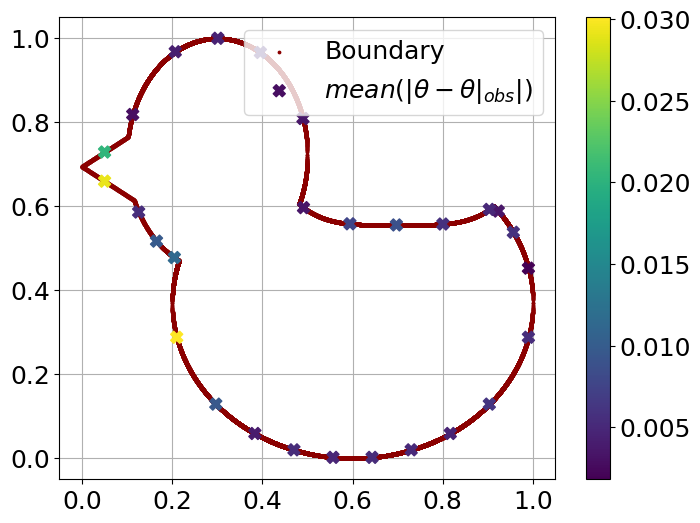

In [36]:
vis = Visualization(cfg,gen, PINN)
vis.plot_obs(save=True,path=r"C:\Users\Voland\Desktop\art\oop3/obs/")

In [9]:
class PINN:
    def __init__(self, config):
        self.cfg = config

        # Pass config to each model
        self.modeltheta = self.MyModelT(self.cfg)
        self.modelphi   = self.MyModelPhi(self.cfg)
        self.modelh     = self.MyModelH(self.cfg)
        self.modelgamma = self.MyModelGamma(self.cfg)

        self.models = [self.modeltheta, self.modelphi,
                       self.modelh, self.modelgamma]

    class BasePINN(tf.keras.Model):
        """
        Base class for PINN models.
        """
        def __init__(self, cfg,
                     num_hidden_layers=3, hidden_dim=30,
                     output_activation='linear',
                     output_init='zeros',
                     use_time=True):

            super().__init__()

            # store config locally
            self.cfg = cfg
            self.use_time = use_time

            # Fourier projections
            self.r_proj = FourierFeatureProjection(
                gaussian_projection=16,
                gaussian_scale=1.0 / cfg.xmax
            )
            self.phi_proj = FourierFeatureProjection(
                gaussian_projection=16,
                gaussian_scale=1.0 / cfg.ymax
            )
            if use_time:
                self.t_proj = FourierFeatureProjection(
                    gaussian_projection=16,
                    gaussian_scale=1.0 / cfg.tmax
                )

            # Hidden layers
            self.hidden_layers = [
                tf.keras.layers.Dense(hidden_dim, activation='tanh')
                for _ in range(num_hidden_layers)
            ]

            # Output layer
            self.output_layer = tf.keras.layers.Dense(
                1,
                activation=output_activation,
                bias_initializer=output_init,
                kernel_initializer='zeros'
            )

            self.c = tf.Variable(1.0, trainable=False, name='c_scale')

        def project_inputs(self, inputs):
            z = self.r_proj(inputs[:, 0:1])
            r = self.phi_proj(inputs[:, 1:2])

            if self.use_time:
                t = self.t_proj(inputs[:, 2:3])
                return tf.concat([z, r, t], 1)
            else:
                return tf.concat([z, r], 1)

        def call(self, inputs):
            x = self.project_inputs(inputs)
            for layer in self.hidden_layers:
                x = layer(x)
            return self.output_layer(x)

    class MyModelT(BasePINN):
        def __init__(self, cfg):
            super().__init__(
                cfg,
                num_hidden_layers=3,
                hidden_dim=30,
                output_activation='linear',
                output_init='ones',
                use_time=True
            )

        def call(self, inputs):
            return super().call(inputs) * self.c

    class MyModelPhi(BasePINN):
        def __init__(self, cfg):
            super().__init__(
                cfg,
                num_hidden_layers=3,
                hidden_dim=30,
                output_activation='sigmoid',
                output_init='ones',
                use_time=True
            )
        def call(self, inputs):
            base = super().call(inputs)
            return  base 
    class MyModelH(BasePINN):
        def __init__(self, cfg):
            super().__init__(
                cfg,
                num_hidden_layers=3,
                hidden_dim=30,
                output_activation='linear',
                output_init='zeros',
                use_time=False
            )

        def call(self, inputs):
            base = super().call(inputs)
            return  10**base + 1e-8

    class MyModelGamma(BasePINN):
        def __init__(self, cfg):
            super().__init__(
                cfg,
                num_hidden_layers=3,
                hidden_dim=30,
                output_activation='sigmoid',
                output_init='ones',
                use_time=False
            )
    def save(self, path):
        # Make folder if needed

        os.makedirs(path, exist_ok=True)
    
        self.modeltheta.save(f"{path}/modeltheta")
        self.modelphi.save(f"{path}/modelphi")
        self.modelh.save(f"{path}/modelh")
        self.modelgamma.save(f"{path}/modelgamma")
    
        print("Models saved to:", path)    
    def load(self, path):
        self.modeltheta = tf.keras.models.load_model(f"{path}modeltheta")
        self.modelphi   = tf.keras.models.load_model(f"{path}modelphi")
        self.modelh     = tf.keras.models.load_model(f"{path}modelh")
        self.modelgamma = tf.keras.models.load_model(f"{path}modelgamma")
        
        self.models = [self.modeltheta, self.modelphi,
                       self.modelh, self.modelgamma]
    

In [10]:
class Train:
    def __init__(self,
                 cfg,
                 gen,
                 pdefunc,
                 PINN,
                vis):

        # models
        self.cfg = cfg
        self.gen = gen
        self.pdefunc = pdefunc
        self.PINN = PINN
        self.vis = vis
        self.hist1 = []
        self.hist2 = []
        self.hist3 = []        
        self.tf_optimizer1 = tf.keras.optimizers.Adam(lr = 2e-4, beta_1=.99)      
        self.tf_optimizer2 = tf.keras.optimizers.Adam(lr = 2e-4, beta_1=.99)   
        self.tf_optimizer3 = tf.keras.optimizers.Adam(lr = 2e-4, beta_1=.99)      
        self.tf_optimizer4 = tf.keras.optimizers.Adam(lr = 2e-4, beta_1=.99)       
        self.tf_optimizer5 = tf.keras.optimizers.Adam(lr = 1e-3, beta_1=.99) 
        # data
        
        # shortcuts
        self.mse = lambda x: tf.reduce_mean( tf.square( x ) )
        self.abs = lambda x: tf.math.abs(x) 



    # ---------------------------------------------------------
    # ------ Shared gradient helper for r1/r2  ----------------
   # ---------------------------------------------------------

    @tf.function
    def _compute_grads_theta_phi(self, x, y, t):

        with tf.GradientTape(persistent=True) as tape:
            tape.watch([x, y, t])
            inp = tf.concat([x, y, t], axis=1)

            theta = self.PINN.models[0](inp)
            phi   = self.PINN.models[1](inp)

            theta_x = tape.gradient(theta, x)
            theta_y = tape.gradient(theta, y)
            phi_x   = tape.gradient(phi, x)
            phi_y   = tape.gradient(phi, y)

        # second derivatives + theta_t
        theta_t  = tape.gradient(theta, t)
        theta_xx = tape.gradient(theta_x, x)
        theta_yy = tape.gradient(theta_y, y)
        phi_xx   = tape.gradient(phi_x, x)
        phi_yy   = tape.gradient(phi_y, y)

        del tape
        return theta, phi, theta_x, theta_y, theta_t, theta_xx, theta_yy, phi_xx, phi_yy

    # ---------------------------------------------------------
    # ---------------- r1  and  r2 -----------------------------
    # ---------------------------------------------------------

    @tf.function
    def get_r(self, X):
        x, y, t = X[:, 0:1], X[:, 1:2], X[:, 2:3]

        theta, phi, theta_x, theta_y, theta_t, theta_xx, theta_yy, phi_xx, phi_yy = self._compute_grads_theta_phi(x, y, t)
        r1 = self.pdefunc.r_1(x, y, t, theta, theta_x, theta_y, theta_t, theta_xx, theta_yy, phi)
        r2 = self.pdefunc.r_2(x, y, t, phi, phi_xx, phi_yy, theta)
        return r1, r2

    # ---------------------------------------------------------
    # ---------------- Boundary terms b1,b2 -------------------
    # ---------------------------------------------------------

    @tf.function
    def get_b(self, X_b, n_b):
        x, y, t = X_b[:, 0:1], X_b[:, 1:2], X_b[:, 2:3]

        with tf.GradientTape(persistent=True) as tape:
            tape.watch([x, y, t])

            inp = tf.concat([x, y, t], axis=1)
            theta = self.PINN.models[0](inp)
            phi = self.PINN.models[1](inp)

        theta_x = tape.gradient(theta, x)
        theta_y = tape.gradient(theta, y)
        phi_x = tape.gradient(phi, x)
        phi_y = tape.gradient(phi, y)
        del tape

        gamma = self.PINN.models[3](tf.concat([x, y], 1)) * (self.cfg.gmax - self.cfg.gmin) + self.cfg.gmin
        h     = self.PINN.models[2](tf.concat([x, y], 1))

        r1 = self.pdefunc.fun_beta(theta, theta_x, theta_y, n_b[:, 0:1], n_b[:, 1:2], h)
        r2 = self.pdefunc.fun_gamma(phi, phi_x, phi_y, n_b[:, 0:1], n_b[:, 1:2], gamma)
        return r1, r2

    # ---------------------------------------------------------
    # ----------------------- Loss -----------------------------
    # ---------------------------------------------------------

    @tf.function
    def compute_loss(self):

        # PDE residuals
        r1, r2 = self.get_r(self.gen.X_data[0])

        # boundary
        theta_b, phi_b = self.get_b(self.gen.X_data[1],self.gen.n_data)


        # initial & tmp conditions
        theta_0    = self.PINN.models[0](self.gen.X_data[2]) - self.gen.u_data[0]
        theta_tmp = self.PINN.models[0](self.gen.X_data[3]) - self.gen.u_data[1]


        # weighted losses
        w1, w2, w3, w4 = self.gen.w_data

        loss_r   = self.mse(w1 * self.abs(r1)) + self.mse(w1 * self.abs(r2))
        loss_b   = self.mse(w2 * self.abs(theta_b)) + self.mse(w2 * self.abs(phi_b))
        loss_0   = self.mse(w3 * self.abs(theta_0))
        loss_tmp = self.mse(w4 * self.abs(theta_tmp))

        loss_all = loss_r + loss_b + loss_0 + loss_tmp

        # second return term unchanged
        detail_loss = (
            self.mse(r1) + self.mse(r2) +
            self.mse(theta_b) + self.mse(phi_b) +
            self.mse(theta_0)
        )

        return loss_all, detail_loss, self.mse(theta_tmp)

    # ---------------------------------------------------------
    # ------------------- Gradient Step ------------------------
    # ---------------------------------------------------------

    @tf.function
    def get_grad(self):
        with tf.GradientTape(persistent=True) as tape:
            loss_all, loss_details, loss_tmp = self.compute_loss()

        gtheta  = tape.gradient(loss_all, self.PINN.models[0].trainable_variables)
        gphi  = tape.gradient(loss_all, self.PINN.models[1].trainable_variables)
        gh  = tape.gradient(loss_all, self.PINN.models[2].trainable_variables)
        ggamma  = tape.gradient(loss_all, self.PINN.models[3].trainable_variables)

        gw = [tape.gradient(loss_all, w) for w in self.gen.w_data]

        del tape
        return loss_all, loss_details, loss_tmp, gtheta, gphi, gh, ggamma, gw[0],gw[1],gw[2],gw[3]


    def fit(self,tf_iter):
        start_time = time.time()
        for epoch in range(tf_iter):
                lossall,loss_,loss_tmp, gtheta, gphi,gh,ggamma, g_w1,g_w2,g_w3,g_w4 = self.get_grad()
                self.hist1.append(lossall)
                self.hist2.append(loss_)  
                self.hist3.append(loss_tmp)             
                self.tf_optimizer1.apply_gradients(zip(gtheta, self.PINN.models[0].trainable_variables))        
                self.tf_optimizer2.apply_gradients(zip(gphi, self.PINN.models[1].trainable_variables))  
                self.tf_optimizer3.apply_gradients(zip(gh, self.PINN.models[2].trainable_variables))  
                self.tf_optimizer4.apply_gradients(zip(ggamma, self.PINN.models[3].trainable_variables))      
#                if loss_>=1e-4:
                self.tf_optimizer5.apply_gradients(zip([-g_w1,-g_w2,-g_w3], [self.gen.w_data[0],self.gen.w_data[1],self.gen.w_data[2]]))              
                # if epoch % 1000 == 0:           
                #     plotu(0,1)       
                #     plotu(tmax/2,1)  
                #     plotu(tmax,1)    
                #     plothg()
#                if epoch % 100 == 0:
#                    elapsed = time.time() - start_time
#                    print('It: %d, Time: %.2f' % (epoch, elapsed))
#        #            tf.print(f"mse_b: {lossb}   mse_0: {loss0}    mse_r: {lossr}  total loss: {losswall}")
                if epoch % 100 == 0:
                    elapsed = time.time() - start_time
                    # Use tf.print for tensors in graph mode
                    tf.print("It:", epoch, "Time:", elapsed, "loss_w:", lossall, "loss:", loss_, "J", loss_tmp)
                    start_time = time.time()
                if epoch%1000 == 0:
                    self.vis.plotu(1.0)



In [11]:
cfg = SimulationConfig()
cfg.summary()
pde = PDEFunctions(cfg)
PINN = PINN(cfg)
gen = DataGenerator(cfg, pde)
vis = Visualization(cfg,gen, PINN)
train = Train(cfg,gen,pde, PINN,vis)


chi: 7.572975950064255e-07
Fo: 0.13631356710115655
Bir: 9.79839440064
alpha: 0.009999999999999998
nn: 9.0
d: 1.0
S: 3.663003663003663


C:\Users\Voland\AppData\Local\Temp\ipykernel_7148\989942030.py:30: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(skopt.__version__) < LooseVersion("0.9"):
C:\Users\Voland\anaconda3\envs\new\lib\site-packages\skopt\sampler\sobol.py:521: UserWarning: The balance properties of Sobol' points require n to be a power of 2. 0 points have been previously generated, then: n=0+8002=8002. 
  warnings.warn(
C:\Users\Voland\AppData\Local\Temp\ipykernel_7148\989942030.py:30: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(skopt.__version__) < LooseVersion("0.9"):
C:\Users\Voland\anaconda3\envs\new\lib\site-packages\skopt\sampler\sobol.py:521: UserWarning: The balance properties of Sobol' points require n to be a power of 2. 0 points have been previously generated, then: n=0+60002=60002. 
  warnings.warn(
C:\Users\Voland\anaconda3\envs\new\lib\site-packages\keras\optimizers\

In [15]:
PINN.load(path=r"C:\Users\Voland\Desktop\art/oop3/models/")

In [17]:
308/11

28.0

In [16]:
gen.X_data[3]

<tf.Tensor: shape=(308, 3), dtype=float32, numpy=
array([[0.1124    , 0.81850994, 0.        ],
       [0.2068    , 0.96799576, 0.        ],
       [0.3012    , 0.999995  , 0.        ],
       [0.3956    , 0.96621114, 0.        ],
       [0.49      , 0.8089585 , 0.        ],
       [0.1256    , 0.58624846, 0.        ],
       [0.1652    , 0.51701903, 0.        ],
       [0.2048    , 0.47793186, 0.        ],
       [0.21      , 0.28807214, 0.        ],
       [0.29666665, 0.1289382 , 0.        ],
       [0.38333333, 0.05903951, 0.        ],
       [0.47      , 0.02010593, 0.        ],
       [0.5566667 , 0.00217976, 0.        ],
       [0.6433333 , 0.00217979, 0.        ],
       [0.73      , 0.02010588, 0.        ],
       [0.81666666, 0.05903957, 0.        ],
       [0.9033333 , 0.12893812, 0.        ],
       [0.99      , 0.28807214, 0.        ],
       [0.9232    , 0.5885861 , 0.        ],
       [0.9566    , 0.53815585, 0.        ],
       [0.99      , 0.45266864, 0.        ],
     

In [ ]:
train.fit(30000)

In [14]:
path = r"C:\Users\Voland\Desktop\art/oop3/func/"
vis.save_all(N=100,path=path)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100


In [ ]:
vis = Visualization(cfg,gen, PINN)
vis.plotu()

In [15]:
vis.make_gif(
    folder_path=path,
    output_path=r"C:\Users\Voland\Desktop\art/oop3/gif/",
    frame_duration=50,   # smoother = smaller value
    pause_frames=50
)

✅ GIF saved as: C:\Users\Voland\Desktop\art/oop3/gif/


In [ ]:
path = r'C:\Users\Voland\Desktop\art/oop3/models/'

In [16]:
PINN.save(path)

INFO:tensorflow:Assets written to: C:\Users\Voland\Desktop\art/oop3/func//modeltheta\assets


INFO:tensorflow:Assets written to: C:\Users\Voland\Desktop\art/oop3/func//modeltheta\assets


INFO:tensorflow:Assets written to: C:\Users\Voland\Desktop\art/oop3/func//modelphi\assets


INFO:tensorflow:Assets written to: C:\Users\Voland\Desktop\art/oop3/func//modelphi\assets


INFO:tensorflow:Assets written to: C:\Users\Voland\Desktop\art/oop3/func//modelh\assets


INFO:tensorflow:Assets written to: C:\Users\Voland\Desktop\art/oop3/func//modelh\assets


INFO:tensorflow:Assets written to: C:\Users\Voland\Desktop\art/oop3/func//modelgamma\assets


INFO:tensorflow:Assets written to: C:\Users\Voland\Desktop\art/oop3/func//modelgamma\assets


Models saved to: C:\Users\Voland\Desktop\art/oop3/func/


In [ ]:
`